# Computational Maths HT Sheet 1 Qs 3-5
### Natan Arnold

**3.** (a) We have $a_n\to0$ as $n\to\infty$, and $\frac{2^{-(n+1)}}{2^{-n}} = \frac12$ for all $n$. So $a_n$ converges linearly.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

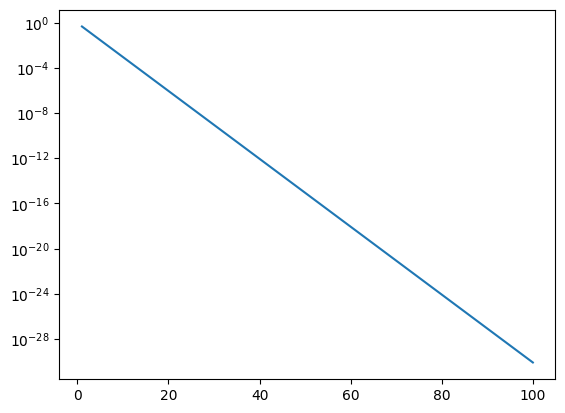

In [9]:
N = 100
a = lambda n: 2 ** (-n)
x = np.arange(1, N+1, dtype=float)
y = a(x)

plt.plot(x, y)
plt.yscale("log")

(b) Again $a_n\to0$ as $n\to\infty$, and ${\displaystyle \lim_{n\to\infty}} \frac{(n+2)^{-1}}{(n+1)^{-1}} = {\displaystyle \lim_{n\to\infty}} \frac{n+1}{n+2} = 1$. So we cannot call the convergence linear, as we need $\mu\in(0,1)$. But for any $q>1$, ${\displaystyle \lim_{n\to\infty}} \frac{(n+2)^{-1}}{(n+1)^{-q}} = {\displaystyle \lim_{n\to\infty}} \frac{(n+1)^q}{n+2} = \infty$. So with the given definition we cannot classify the order of convergence.

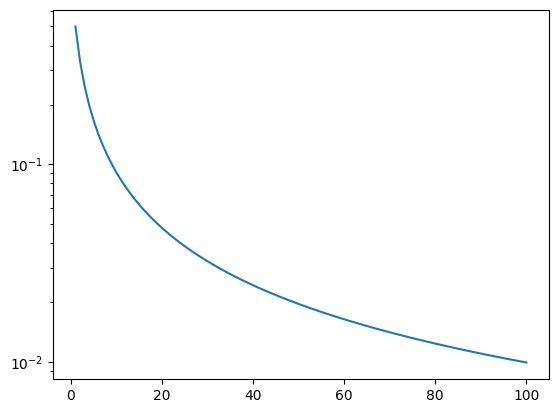

In [10]:
N = 100
a = lambda n: 1 / (n+1)
x = np.arange(1, N+1, dtype=float)
y = a(x)

plt.plot(x, y)
plt.yscale("log")

(c) Again $a_n\to0$ as $n\to\infty$. So we have
$$
\begin{align*}
  \lim_{n\to\infty} \frac{2^{-2^{n+1}}}{\left(2^{-2^n}\right)^q}
  &= \lim_{n\to\infty} \frac{2^{-2\left(2^n\right)}}{2^{-q\left(2^n\right)}} \\
  &= \lim_{n\to\infty} 2^{(q-2)\left(2^n\right)} \\
  &= \lim_{n\to\infty} \left(2^{2^n}\right)^{q-2} \\
  &= \begin{cases}
    0 & q<2 \\
    1 & q=2 \\
    \infty & q>2
  \end{cases}
\end{align*}
$$
Thus the sequence converges quadratically.

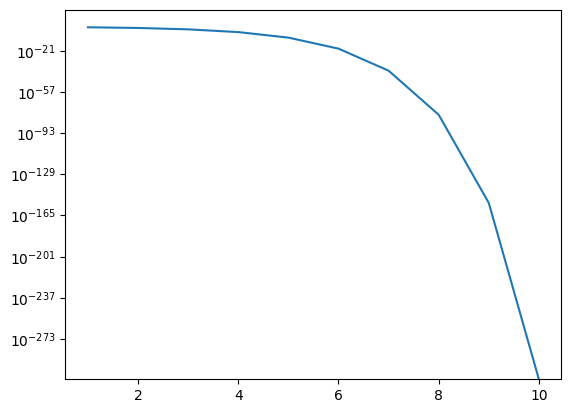

In [30]:
N = 10
a = lambda n: 2 ** (-2**n)
x = np.arange(1, N+1, dtype=float)
y = a(x)

plt.yscale("log")
plt.plot(x, y)

Interestingly, for this one, if we take a double log of $y$ (equivalent to plotting $\log y$ on a logarithmic axis), then we get a linear plot:

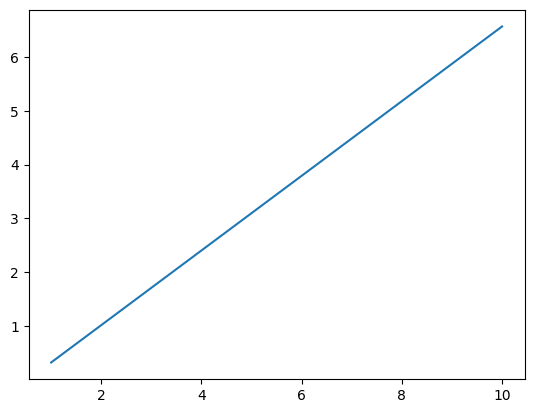

In [31]:
plt.plot(x, np.log(-np.log(y))) # Negation to keep values positive for the second log

**4.** (a) Observe that $g(\frac{3\pi}4) = \frac{3\pi}4+\frac1{\sqrt2} < \frac{5\pi}4$ and $g(\frac{5\pi}4) = \frac{5\pi}4-\frac1{\sqrt2} > \frac{3\pi}4$, and $g$ is non-decreasing, so $g(x) \in [ \frac{3\pi}4+\frac1{\sqrt2}, \frac{5\pi}4-\frac1{\sqrt2} ] \subseteq X$ for all $x\in X$, so $g$ is endomorphic.

Also, $g'(x) = \cos x + 1 \in [0, 1-\frac1{\sqrt2}]$ for all $x\in X$. So $|g'(x)<1$ for all $x\in X$. So $g$ is a contraction. Thus Banach's contraction mapping theorem applies.

(b) $g(0) = -3 \notin X$ so $g$ is not endomorphic. Then Banach's contraction mapping theorem does not apply.

(c) Clearly $g(X) \subseteq X$, as $g(x)>x$. So $g$ is endomorphic. Also, $g'(x) = 1 - \frac1{x^2} < 1$, so so $g$ is a contraction. Then Banach's contraction mapping theorem applies.

**5.** (a) We have $e_{n+1} = Me^q$, and $e_{n+2} = Me_{n+1}^q = M^{q+1}e^{2q}$. Taking logs of each of these gives the system of equations
$$ \begin{align}
  \log e_{n+1} &= \log M + q \log e_n \\
  \log e_{n+2} &= (q+1)\log M + 2q\log e_n
\end{align} $$
Rearrange $(1)$ to give $\log M$ in terms of $q$, then substitute into $(2)$ to find a quadratic in $p$, whose solution can then be used to find $\log M$.

(b) First we will find the $e_n$ for $n=10\ 000, 10\ 001, 10\ 002$:

In [97]:
from mpmath import mp, mpf, polyroots
mp.dps = 100

In [107]:
def leibniz(n):
  p = mpf(0)
  for i in range(n+1):
    p += (-1)**i / (2*i+1)
  return 4*p

In [108]:
e0 = abs(mp.pi - leibniz(10000))
e1 = abs(mp.pi - leibniz(10001))
e2 = abs(mp.pi - leibniz(10002))
E0, E1, E2 = mp.log(e0), mp.log(e1), mp.log(e2)

We can then do the steps above to get the quadratic $E_0q^2 - (E_0+E_1)q + (E_2-E_1) = 0$, which `numpy` can solve:

In [109]:
logM = polyroots([E0, -E0-E1, E2-E1])
M = mp.exp(logM[0])
q = (E1 - logM[0]) / E0
print("M =", M)
print("q =", q)
print("e1, e2 calculated using M and q:")
print("e1:", M * e0**q)
print("e2:", M * (M * e0**q)**q)
print("Actual:")
print("e1:", e1)
print("e2:", e2)

M = 1.000005427265062909119725646687193479756409953435605718601792756930714137737662803497665187578227003
q = 1.000011444865962308465741327545606055861843962833379864014917727909639603526654273011091467421625432
e1, e2 calculated using M and q:
e1: 0.00009998000374918442667660335422102878484707001783939488851881105781640628620899862803482534211706797928
e2: 0.00009997000763333123489419541744301058865029349420526102560267682832715738897614595261021376890630195737
Actual:
e1: 0.00009998000374918442667660335422102878484707001783939488851881105781640628620899862803482534211706797928
e2: 0.00009997000874769134897473598110490012939721669814494959390306394218359371379100137196517465788293202072


I've chosen the solution $M=1.000005427, \: q=1.000011445$, as the other pair gives an inaccurate value for $e_{n+2}$ (I'm not sure why).

Since $q$ is very close to 1, it would seem that the sequence converges linearly.

(c)

In [153]:
# Having this as a generator allows us to neatly compute the first N approximations for pi without having to do the whole sum separately each time
def leibniz_gen():
  p = mpf(0)
  i = 0
  while True:
    p += 4 * (-1)**i / (2*i+1)
    yield p
    i += 1

In [154]:
def aitken(seq):
  a0 = next(seq)
  a1 = next(seq)
  a2 = next(seq)
  while True:
    yield a0 - (a1 - a0)**2 / (a2 - 2*a1 + a0)
    a0, a1, a2 = a1, a2, next(seq)

In [164]:
L = leibniz_gen()
A = aitken(leibniz_gen())
AA = aitken(aitken(leibniz_gen()))

X = range(10001)
Y1, Y2, Y3 = [], [], []
for i in X:
  Y1.append(abs(next(L) - mp.pi))
  Y2.append(abs(next(A) - mp.pi))
  Y3.append(abs(next(AA) - mp.pi))

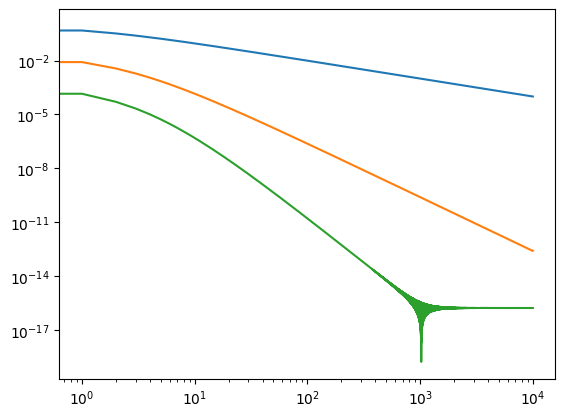

In [166]:
plt.plot(X, Y1)
plt.plot(X, Y2)
plt.plot(X, Y3)
plt.xscale("log")
plt.yscale("log")

(d) Based on the gradients of the log-log plot, it seems that $\tilde{a}_n$ has quadratic convergence, and $\tilde{\tilde{a}}_n$ has quartic convergence.